In [1]:

import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [2]:
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

In [3]:
len(X_train)

60000

In [4]:
len(X_test)

10000

In [5]:

X_train[0].shape

(28, 28)

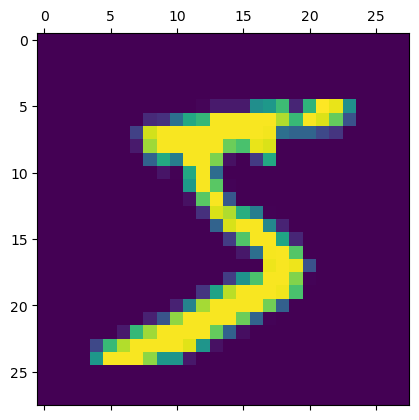

In [6]:

plt.matshow(X_train[0])

In [7]:
y_train[0]

np.uint8(5)

In [8]:
X_train = X_train / 255
X_test = X_test / 255

In [9]:

X_train_flattened = X_train.reshape(len(X_train), 28*28)
X_test_flattened = X_test.reshape(len(X_test), 28*28)

In [10]:

X_train_flattened.shape

(60000, 784)

In [11]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5)

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9208 - loss: 0.2796
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9625 - loss: 0.1268
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9736 - loss: 0.0876
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9801 - loss: 0.0662
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9834 - loss: 0.0529


In [12]:

model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9731 - loss: 0.0899


[0.08989685028791428, 0.9731000065803528]

In [16]:

model.export("./saved_model")

INFO:tensorflow:Assets written to: ./saved_model\assets


INFO:tensorflow:Assets written to: ./saved_model\assets


Saved artifact at './saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2522500345744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2522500343824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2522500348240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2522500343440: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [17]:

converter = tf.lite.TFLiteConverter.from_saved_model("./saved_model")
tflite_model = converter.convert()

In [18]:
converter = tf.lite.TFLiteConverter.from_saved_model("./saved_model")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()

In [19]:

len(tflite_model)

320788

In [20]:
len(tflite_quant_model)

86848

In [21]:

with open("tflite_model.tflite", "wb") as f:
    f.write(tflite_model)

In [22]:
with open("tflite_quant_model.tflite", "wb") as f:
    f.write(tflite_quant_model)

In [24]:
!pip install tensorflow-model-optimization


  Attempting uninstall: absl-py

    Found existing installation: absl-py 2.4.0

    Uninstalling absl-py-2.4.0:

      Successfully uninstalled absl-py-2.4.0

   ---------- ----------------------------- 1/4 [absl-py]
   ------------------------------ --------- 3/4 [tensorflow-model-optimization]
   ------------------------------ --------- 3/4 [tensorflow-model-optimization]
   ------------------------------ --------- 3/4 [tensorflow-model-optimization]
   ------------------------------ --------- 3/4 [tensorflow-model-optimization]
   ------------------------------ --------- 3/4 [tensorflow-model-optimization]
   ---------------------------------------- 4/4 [tensorflow-model-optimization]



In [32]:
import tensorflow as tf
import tensorflow_model_optimization as tfmot
import tf_keras as keras

# ====================== Correct Model with Flatten ======================
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),     # ← This fixes the error
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ====================== Quantization Aware Training ======================
quantize_model = tfmot.quantization.keras.quantize_model

q_aware_model = quantize_model(model)

q_aware_model.compile(optimizer='adam',
                      loss=keras.losses.SparseCategoricalCrossentropy(),
                      metrics=['accuracy'])

print("\n✅ Quantization Aware Model Ready!")
q_aware_model.summary()

# ====================== Train ======================
q_aware_model.fit(X_train, y_train, 
                  epochs=5, 
                  validation_data=(X_test, y_test),
                  batch_size=128)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense_2 (Dense)             (None, 128)               100480    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_3 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101770 (397.54 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

✅ Quantization Aware Model Ready!
Model: "sequential_1"
_________________________________________________________________
 Layer (type)          

469/469 [==============================] - 3s 4ms/step - loss: 0.4031 - accuracy: 0.8863 - val_loss: 0.1944 - val_accuracy: 0.9453
Epoch 2/5
469/469 [==============================] - 2s 5ms/step - loss: 0.1909 - accuracy: 0.9446 - val_loss: 0.1335 - val_accuracy: 0.9618
Epoch 3/5
469/469 [==============================] - 2s 4ms/step - loss: 0.1428 - accuracy: 0.9587 - val_loss: 0.1097 - val_accuracy: 0.9691
Epoch 4/5
469/469 [==============================] - 2s 4ms/step - loss: 0.1162 - accuracy: 0.9661 - val_loss: 0.0967 - val_accuracy: 0.9714
Epoch 5/5
469/469 [==============================] - 2s 4ms/step - loss: 0.0992 - accuracy: 0.9705 - val_loss: 0.0879 - val_accuracy: 0.9740


In [33]:

q_aware_model.fit(X_train, y_train, epochs=1)

1875/1875 [==============================] - 5s 3ms/step - loss: 0.1016 - accuracy: 0.9689


In [34]:

q_aware_model.evaluate(X_test, y_test)

313/313 [==============================] - 0s 1ms/step - loss: 0.0785 - accuracy: 0.9765


[0.07852079719305038, 0.9764999747276306]

In [35]:
converter = tf.lite.TFLiteConverter.from_keras_model(q_aware_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_qaware_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmpb_x7qnks\assets


INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmpb_x7qnks\assets
C:\Users\user\anaconda3\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [36]:
len(tflite_qaware_model)

105136

In [37]:
with open("tflite_qaware_model.tflite", 'wb') as f:
    f.write(tflite_qaware_model)